# Multi-scale Gaussian smoothing (per-pixel sigma)

Smoothing with a Gaussian whose **kernel width depends on the pixel** via **multi-scale blending**: we compute \(k\) images smoothed at \(k\) different constant sigmas, then at each pixel blend them using weights derived from a desired \(\sigma(x,y)\) map. No built-in for this in scipy/cupy; we implement it and compare to reference constant-sigma smoothing.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from datetime import datetime
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu

In [2]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/"
ts = 0.25
n_x = n_y = 256
x = np.linspace(0, 0.584, n_x, endpoint=True)
y = np.linspace(0, 0.584, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
dx = x[1] - x[0]

X_train = np.load(pth + "t{:.2f}_X_train.npy".format(ts)).T
points = np.load(pth + "points.npy")
X_train_grid = np.empty((len(X_train), n_x * n_y))
gridded = griddata(points[:, :2], X_train.T, (X, Y), method="linear")
failed = np.isnan(gridded)
gridded[failed] = griddata(points[:, :2], X_train.T, (X, Y), method="nearest")[failed]
X_train_grid[:] = gridded.reshape((n_x * n_y, len(X_train))).T

shape = (n_x, n_y)
img0 = X_train_grid[0].reshape(shape).copy()  # one snapshot for testing

## Reference: constant-sigma scipy Gaussian

In [13]:
sigma_ref = 0.013  # world units
sgm_px = sigma_ref / dx
truncate = 8
t1 = datetime.now()
img_ref = gaussian_filter(img0, sigma=sgm_px, truncate=truncate, mode="reflect")
t2 = datetime.now()
print((t2-t1).total_seconds())

0.014721


## Multi-scale blending (CPU)

Precompute \(k\) smoothed images at sigmas \(\sigma_1 < \cdots < \sigma_k\). At each pixel, compute blend weights by linear interpolation in sigma (or log-sigma) between the two bracketing levels; output = \(\sum_s w_s \, I_s\).

In [4]:
def multiscale_gaussian_blend(img, sigma_map, k=5, dx=1.0, truncate=8, mode="reflect", use_log=True):
    """
    img: (H, W)
    sigma_map: (H, W) desired sigma in world units at each pixel.
    k: number of scale levels.
    dx: grid spacing (world units).
    use_log: if True, levels are log-spaced in sigma; else linear.
    Returns: (H, W) blended smoothed image.
    """
    sigma_flat = sigma_map.ravel()
    sigma_min, sigma_max = float(np.nanmin(sigma_flat)), float(np.nanmax(sigma_flat))
    if sigma_max <= sigma_min:
        sigma_max = sigma_min + 1e-12
    if use_log:
        levels = np.exp(np.linspace(np.log(sigma_min), np.log(sigma_max), k))
    else:
        levels = np.linspace(sigma_min, sigma_max, k)
    levels_px = levels / dx

    smoothed = np.stack([gaussian_filter(img, sigma=s, truncate=truncate, mode=mode) for s in levels_px], axis=0)

    sigma_map_safe = np.clip(sigma_map, sigma_min, sigma_max)
    if use_log:
        log_sigma = np.log(sigma_map_safe)
        log_levels = np.log(levels)
        idx = np.searchsorted(log_levels, log_sigma.ravel(), side="right")
    else:
        idx = np.searchsorted(levels, sigma_map_safe.ravel(), side="right")
    idx = np.clip(idx, 1, k - 1)
    s_lo, s_hi = levels[idx - 1], levels[idx]
    if use_log:
        t = (np.log(sigma_map_safe.ravel()) - np.log(s_lo)) / (np.log(s_hi) - np.log(s_lo) + 1e-12)
    else:
        t = (sigma_map_safe.ravel() - s_lo) / (s_hi - s_lo + 1e-12)
    t = np.clip(t, 0, 1).ravel()
    r, c = np.unravel_index(np.arange(img.size), img.shape)
    v_lo = smoothed[(idx - 1), r, c]
    v_hi = smoothed[idx, r, c]
    out_flat = (1 - t) * v_lo + t * v_hi
    return out_flat.reshape(img.shape)

In [14]:
# Constant sigma_map -> should match reference
sigma_map_const = np.full_like(img0, sigma_ref)
t1 = datetime.now()
img_multiscale_const = multiscale_gaussian_blend(img0, sigma_map_const, k=5, dx=dx, truncate=truncate, mode="reflect")
t2 = datetime.now()
print((t2-t1).total_seconds())
print(np.allclose(img_multiscale_const, img_ref))

0.074154
True


## CuPy version (efficient)

Same logic: \(k\) `gaussian_filter_gpu` calls, then weights and sum on GPU.

In [18]:
def multiscale_gaussian_blend_gpu(img, sigma_map, k=5, dx=1.0, truncate=8, mode="reflect", use_log=True):
    """CuPy version: img and sigma_map can be numpy; internal work on GPU."""

    img_gpu = cp.asarray(img.astype(np.float64))
    sigma_map_gpu = cp.asarray(sigma_map.astype(np.float64))

    sigma_flat = sigma_map_gpu.ravel()
    sigma_min = float(cp.nanmin(sigma_flat))
    sigma_max = float(cp.nanmax(sigma_flat))
    if sigma_max <= sigma_min:
        sigma_max = sigma_min + 1e-12
    if use_log:
        levels = np.exp(np.linspace(np.log(sigma_min), np.log(sigma_max), k))
    else:
        levels = np.linspace(sigma_min, sigma_max, k)
    levels_px = levels / dx

    smoothed = cp.stack([gaussian_filter_gpu(img_gpu, sigma=s, truncate=truncate, mode=mode) for s in levels_px], axis=0)

    sigma_map_safe = cp.clip(sigma_map_gpu, sigma_min, sigma_max)
    if use_log:
        log_sigma = cp.log(sigma_map_safe)
        log_levels = np.log(levels)
        idx = np.searchsorted(log_levels, cp.asnumpy(log_sigma).ravel(), side="right")
    else:
        idx = np.searchsorted(levels, cp.asnumpy(sigma_map_safe).ravel(), side="right")
    idx = np.clip(idx, 1, k - 1)
    s_lo, s_hi = levels[idx - 1], levels[idx]
    if use_log:
        t = (cp.asnumpy(log_sigma).ravel() - np.log(s_lo)) / (np.log(s_hi) - np.log(s_lo) + 1e-12)
    else:
        t = (cp.asnumpy(sigma_map_safe).ravel() - s_lo) / (s_hi - s_lo + 1e-12)
    t = np.clip(t, 0, 1).ravel()
    r, c = np.unravel_index(np.arange(img.size), img.shape)
    sm_lo = cp.asnumpy(smoothed[(idx - 1), r, c])
    sm_hi = cp.asnumpy(smoothed[idx, r, c])
    out_flat = (1 - t) * sm_lo + t * sm_hi
    return out_flat.reshape(img.shape)

In [19]:
img_multiscale_gpu = multiscale_gaussian_blend_gpu(img0, sigma_map_const, k=5, dx=dx, truncate=truncate, mode="reflect")

## Spatially varying sigma (demo)

e.g. sigma increases with distance from center.

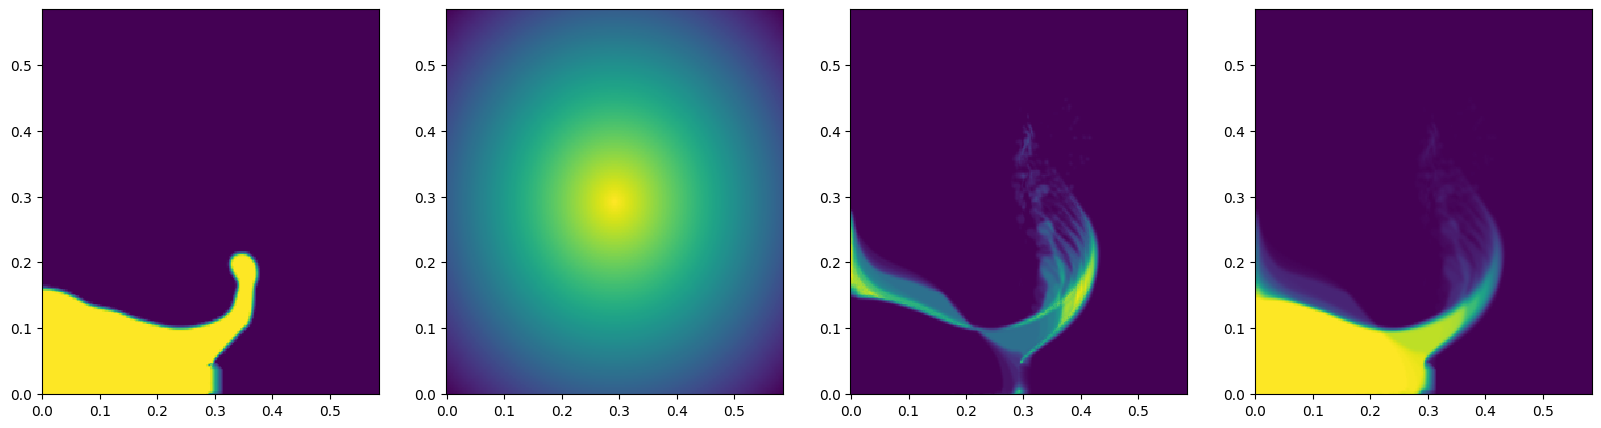

In [47]:
cx, cy = (x[-1] + x[0]) / 2, (y[-1] + y[0]) / 2
dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
sigma_map_varying = sigma_ref * (1-dist / (dist.max() + 1e-12)) *2
img_multiscale_varying = multiscale_gaussian_blend(img0, sigma_map_varying, k=100, dx=dx, truncate=truncate, mode="reflect")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].pcolormesh(X, Y, img0, shading="auto")
axes[1].pcolormesh(X, Y, sigma_map_varying, shading="auto")
axes[2].pcolormesh(X, Y, np.var(X_train_grid,axis=0).reshape(shape), shading="auto")
axes[3].pcolormesh(X, Y, np.mean(X_train_grid,axis=0).reshape(shape), shading="auto")


## Plots (pcolormesh)

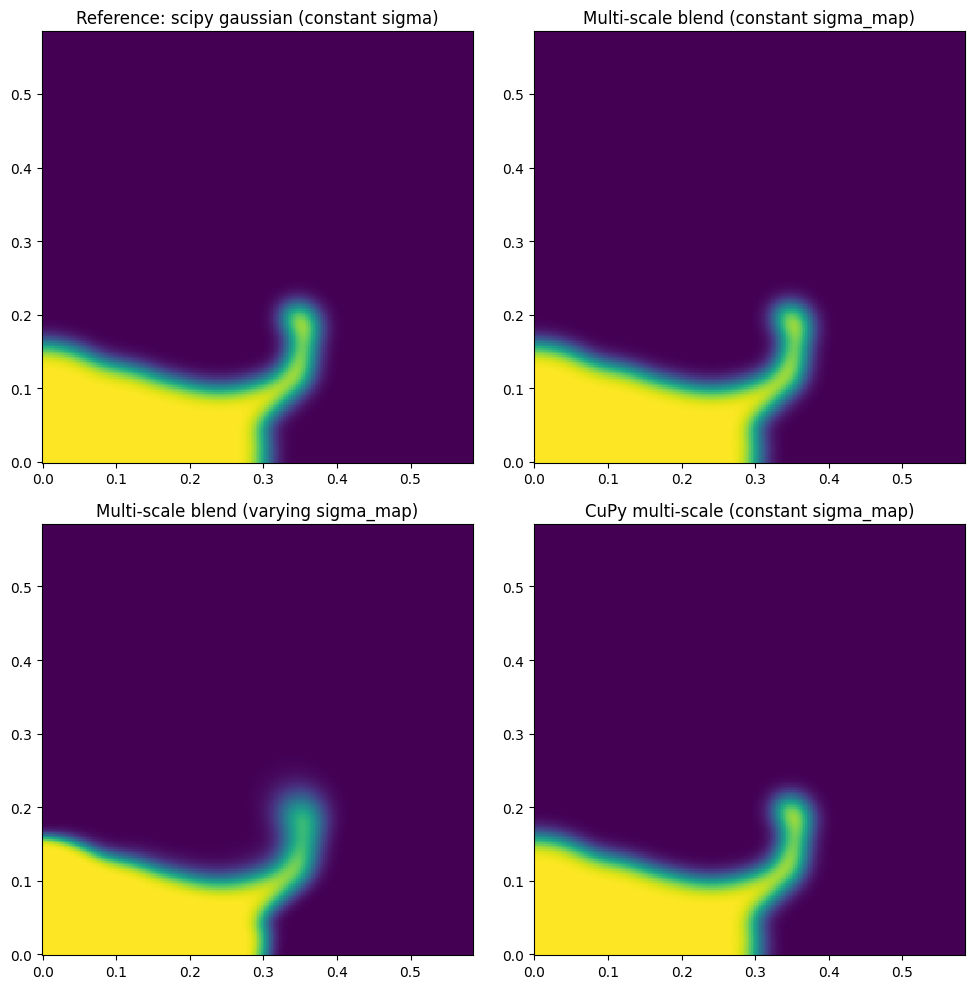

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].pcolormesh(X, Y, img_ref, shading="auto")
axes[0, 0].set_title("Reference: scipy gaussian (constant sigma)")
axes[0, 0].set_aspect("equal")

axes[0, 1].pcolormesh(X, Y, img_multiscale_const, shading="auto")
axes[0, 1].set_title("Multi-scale blend (constant sigma_map)")
axes[0, 1].set_aspect("equal")

axes[1, 0].pcolormesh(X, Y, img_multiscale_varying, shading="auto")
axes[1, 0].set_title("Multi-scale blend (varying sigma_map)")
axes[1, 0].set_aspect("equal")

if HAS_CUPY:
    axes[1, 1].pcolormesh(X, Y, img_multiscale_gpu, shading="auto")
    axes[1, 1].set_title("CuPy multi-scale (constant sigma_map)")
else:
    axes[1, 1].pcolormesh(X, Y, img_multiscale_const, shading="auto")
    axes[1, 1].set_title("CuPy N/A (same as const)")
axes[1, 1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [21]:
print("Reference vs multi-scale (const):", np.allclose(img_ref, img_multiscale_const, atol=1e-5, rtol=1e-4))
print("Reference vs GPU (const):", np.allclose(img_ref, img_multiscale_gpu, atol=1e-5, rtol=1e-4))

Reference vs multi-scale (const): True
Reference vs GPU (const): True
